# Lab4

## 1 level

In [2]:

import pandas as pd
import numpy as np
import timeit
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr
from sklearn.preprocessing import OneHotEncoder

print("Ready!")



Ready!


### Dataframe

In [6]:
start_time = timeit.default_timer()

names = ['date', 'time', 'global_active_power', 'global_reactive_power', 'voltage', 'global_intensity', 'sub_metering_1', 
                'sub_metering_2', 'sub_metering_3']

# Read the data
df = pd.read_csv('household_power_consumption.txt', sep=';', header=0, names = names, low_memory = False)
df.replace('?', np.nan, inplace=True)
df.dropna(inplace=True)
df[['global_active_power', 'global_reactive_power', 'voltage', 'global_intensity', 'sub_metering_1', 
                'sub_metering_2', 'sub_metering_3']] = df[['global_active_power', 'global_reactive_power', 'voltage', 'global_intensity', 'sub_metering_1', 
                'sub_metering_2', 'sub_metering_3']].astype(float)
df['date'] = pd.to_datetime(df['date'], dayfirst=True) 
stop_time = timeit.default_timer()

print("\nExec time: ", stop_time - start_time)
print(df.head())
print(df.info())



Exec time:  3.4393946999916807
        date      time  global_active_power  global_reactive_power  voltage  \
0 2006-12-16  17:24:00                4.216                  0.418   234.84   
1 2006-12-16  17:25:00                5.360                  0.436   233.63   
2 2006-12-16  17:26:00                5.374                  0.498   233.29   
3 2006-12-16  17:27:00                5.388                  0.502   233.74   
4 2006-12-16  17:28:00                3.666                  0.528   235.68   

   global_intensity  sub_metering_1  sub_metering_2  sub_metering_3  
0              18.4             0.0             1.0            17.0  
1              23.0             0.0             1.0            16.0  
2              23.0             0.0             2.0            17.0  
3              23.0             0.0             1.0            17.0  
4              15.8             0.0             1.0            17.0  
<class 'pandas.core.frame.DataFrame'>
Index: 2049280 entries, 0 to 207525

### array

In [7]:
start_time = timeit.default_timer()

dtype = [('date', 'U10'), ('time', 'U8'), ('global_active_power', float), ('global_reactive_power', float), ('voltage', float), ('global_intensity', float), ('sub_metering_1', float), ('sub_metering_2', float), ('sub_metering_3', float)]
data = np.genfromtxt('household_power_consumption.txt', delimiter=';', skip_header=1, dtype=dtype, filling_values=0)

stop_time = timeit.default_timer()
print("\nExec time: ", stop_time - start_time)
print(data[:5])



Exec time:  6.15922679999494
[('16/12/2006', '17:24:00', 4.216, 0.418, 234.84, 18.4, 0., 1., 17.)
 ('16/12/2006', '17:25:00', 5.36 , 0.436, 233.63, 23. , 0., 1., 16.)
 ('16/12/2006', '17:26:00', 5.374, 0.498, 233.29, 23. , 0., 2., 17.)
 ('16/12/2006', '17:27:00', 5.388, 0.502, 233.74, 23. , 0., 1., 17.)
 ('16/12/2006', '17:28:00', 3.666, 0.528, 235.68, 15.8, 0., 1., 17.)]


Обрати всі записи, у яких загальна активна споживана потужність
перевищує 5 кВт.

In [8]:
start_time = timeit.default_timer()
filtered_df = df[df['global_active_power'] > 5]
stop_time = timeit.default_timer()

print("\nExec time: ", stop_time - start_time)
print(filtered_df.head())


Exec time:  0.00781979999737814
         date      time  global_active_power  global_reactive_power  voltage  \
1  2006-12-16  17:25:00                5.360                  0.436   233.63   
2  2006-12-16  17:26:00                5.374                  0.498   233.29   
3  2006-12-16  17:27:00                5.388                  0.502   233.74   
11 2006-12-16  17:35:00                5.412                  0.470   232.78   
12 2006-12-16  17:36:00                5.224                  0.478   232.99   

    global_intensity  sub_metering_1  sub_metering_2  sub_metering_3  
1               23.0             0.0             1.0            16.0  
2               23.0             0.0             2.0            17.0  
3               23.0             0.0             1.0            17.0  
11              23.2             0.0             1.0            17.0  
12              22.4             0.0             1.0            16.0  


In [9]:
start_time = timeit.default_timer()
filtered = np.where(data['global_active_power'] > 5)
filtered_data = data[filtered]
stop_time = timeit.default_timer()

print("\nExec time: ", stop_time - start_time)
print(filtered_data[:5])



Exec time:  0.0318703000084497
[('16/12/2006', '17:25:00', 5.36 , 0.436, 233.63, 23. , 0., 1., 16.)
 ('16/12/2006', '17:26:00', 5.374, 0.498, 233.29, 23. , 0., 2., 17.)
 ('16/12/2006', '17:27:00', 5.388, 0.502, 233.74, 23. , 0., 1., 17.)
 ('16/12/2006', '17:35:00', 5.412, 0.47 , 232.78, 23.2, 0., 1., 17.)
 ('16/12/2006', '17:36:00', 5.224, 0.478, 232.99, 22.4, 0., 1., 16.)]


Обрати всі записи, у яких вольтаж перевищую 235 В.

In [10]:
# Using Pandas DataFrame
start_time = timeit.default_timer()
filtered_voltage_df = df[df['voltage'] > 235]
stop_time = timeit.default_timer()
print("\nExec time (Pandas):", stop_time - start_time)
print(filtered_voltage_df.head())

# Using NumPy array
start_time = timeit.default_timer()
filtered_voltage_np = np.where(data['voltage'] > 235)
filtered_voltage_data = data[filtered_voltage_np]
stop_time = timeit.default_timer()
print("\nExec time (NumPy):", stop_time - start_time)
print(filtered_voltage_data[:5])


Exec time (Pandas): 0.09110190000501461
         date      time  global_active_power  global_reactive_power  voltage  \
4  2006-12-16  17:28:00                3.666                  0.528   235.68   
5  2006-12-16  17:29:00                3.520                  0.522   235.02   
6  2006-12-16  17:30:00                3.702                  0.520   235.09   
7  2006-12-16  17:31:00                3.700                  0.520   235.22   
14 2006-12-16  17:38:00                4.054                  0.422   235.24   

    global_intensity  sub_metering_1  sub_metering_2  sub_metering_3  
4               15.8             0.0             1.0            17.0  
5               15.0             0.0             2.0            17.0  
6               15.8             0.0             1.0            17.0  
7               15.8             0.0             1.0            17.0  
14              17.6             0.0             1.0            17.0  

Exec time (NumPy): 0.1456711000064388
[('16/12/2006

Обрати всі записи, у яких сила струму лежить в межах 19-20 А,
для них виявити ті, у яких пральна машина та холодильних
споживають більше, ніж бойлер та кондиціонер.

In [11]:
# Using Pandas DataFrame
start_time = timeit.default_timer()
filtered_current_df = df[(df['global_intensity'] >= 19) & (df['global_intensity'] <= 20)]
result_df = filtered_current_df[(filtered_current_df['sub_metering_2'] + filtered_current_df['sub_metering_3']) > 
                                (filtered_current_df['sub_metering_1'] + filtered_current_df['global_reactive_power'])]
stop_time = timeit.default_timer()
print("\nExec time (Pandas):", stop_time - start_time)
print(result_df.head())

# Using NumPy array
start_time = timeit.default_timer()
filtered_current_np = np.where((data['global_intensity'] >= 19) & (data['global_intensity'] <= 20))
filtered_current_data = data[filtered_current_np]
result_np = np.where((filtered_current_data['sub_metering_2'] + filtered_current_data['sub_metering_3']) > 
                     (filtered_current_data['sub_metering_1'] + filtered_current_data['global_reactive_power']))
result_data = filtered_current_data[result_np]
stop_time = timeit.default_timer()
print("\nExec time (NumPy):", stop_time - start_time)
print(result_data[:5])


Exec time (Pandas): 0.008060199994361028
         date      time  global_active_power  global_reactive_power  voltage  \
10 2006-12-16  17:34:00                4.448                  0.498   232.86   
24 2006-12-16  17:48:00                4.474                  0.000   234.96   
33 2006-12-16  17:57:00                4.512                  0.000   233.62   
45 2006-12-16  18:09:00                4.464                  0.136   234.66   
52 2006-12-16  18:16:00                4.524                  0.076   234.20   

    global_intensity  sub_metering_1  sub_metering_2  sub_metering_3  
10              19.6             0.0             1.0            17.0  
24              19.4             0.0             0.0            17.0  
33              19.2             0.0             0.0            17.0  
45              19.0             0.0            37.0            16.0  
52              19.6             0.0             9.0            17.0  

Exec time (NumPy): 0.04413419999764301
[('16/12/20

Обрати випадковим чином 500000 записів (без повторів елементів
вибірки), для них обчислити середні величини усіх 3-х груп
споживання електричної енергії

In [13]:
# Using Pandas DataFrame
start_time = timeit.default_timer()
sampled_df = df.sample(n=500000, replace=False, random_state=42)
mean_values_df = sampled_df[['sub_metering_1', 'sub_metering_2', 'sub_metering_3']].mean()
stop_time = timeit.default_timer()
print("\nExec time (Pandas):", stop_time - start_time)
print("Mean values (Pandas):")
print(mean_values_df)

# Using NumPy array
start_time = timeit.default_timer()
indices = np.random.choice(data.shape[0], size=500000, replace=False)
sampled_data = data[indices]
mean_values_np = {
    'sub_metering_1': np.mean(sampled_data['sub_metering_1']),
    'sub_metering_2': np.mean(sampled_data['sub_metering_2']),
    'sub_metering_3': np.mean(sampled_data['sub_metering_3']),
}
stop_time = timeit.default_timer()
print("\nExec time (NumPy):", stop_time - start_time)
print("Mean values (NumPy):")
for key, value in mean_values_np.items():
    print(f"{key}: {value:.2f}")


Exec time (Pandas): 0.12847540000802837
Mean values (Pandas):
sub_metering_1    1.119258
sub_metering_2    1.308912
sub_metering_3    6.452950
dtype: float64

Exec time (NumPy): 0.15493900000001304
Mean values (NumPy):
sub_metering_1: 1.10
sub_metering_2: 1.29
sub_metering_3: 6.37


Обрати ті записи, які після 18-00 споживають понад 6 кВт за
хвилину в середньому, серед відібраних визначити ті, у яких
основне споживання електроенергії у вказаний проміжок часу
припадає на пральну машину, сушарку, холодильник та освітлення
(група 2 є найбільшою), а потім обрати кожен третій результат із
першої половини та кожен четвертий результат із другої половини.

In [14]:

start_time = timeit.default_timer()

filtered_df = df[(df['time'] > '18:00:00') & (df['global_active_power'] > 6) & (df['sub_metering_2'] > df['sub_metering_1']) & 
                    (df['sub_metering_2'] > df['sub_metering_3'])]

first = filtered_df.iloc[0:len(filtered_df)//2:3]
second = filtered_df.iloc[len(filtered_df)//2:len(filtered_df):4]
result = pd.concat([first, second])

stop_time = timeit.default_timer()

print("\nExec time: ", stop_time - start_time)
print(result.head())


Exec time:  0.08752459997776896
            date      time  global_active_power  global_reactive_power  \
41    2006-12-16  18:05:00                6.052                  0.192   
44    2006-12-16  18:08:00                6.308                  0.116   
17494 2006-12-28  20:58:00                6.386                  0.374   
17498 2006-12-28  21:02:00                8.088                  0.262   
17501 2006-12-28  21:05:00                7.230                  0.152   

       voltage  global_intensity  sub_metering_1  sub_metering_2  \
41      232.93              26.2             0.0            37.0   
44      232.25              27.0             0.0            36.0   
17494   236.63              27.0             1.0            36.0   
17498   235.50              34.4             1.0            72.0   
17501   235.22              30.6             1.0            73.0   

       sub_metering_3  
41               17.0  
44               17.0  
17494            17.0  
17498            

In [15]:
start_time = timeit.default_timer()

filtered_data1 = np.where((data['time'] > '18:00:00') & (data['global_active_power'] > 6) & (data['sub_metering_2'] > data['sub_metering_1']) & 
                               (data['sub_metering_2'] > data['sub_metering_3']))
filtered_data = data[filtered_data1]

first = np.arange(0, len(filtered_data)//2, 3)
second = np.arange(len(filtered_data)//2, len(filtered_data), 4)

first_half = filtered_data[:len(filtered_data)//2: 3]
second_half = filtered_data[len(filtered_data)//2::4]

result = np.concatenate([first_half, second_half])

stop_time = timeit.default_timer()

print("\nExec time: ", stop_time - start_time)
print(result[:5])



Exec time:  0.10664440001710318
[('16/12/2006', '18:05:00', 6.052, 0.192, 232.93, 26.2, 0., 37., 17.)
 ('16/12/2006', '18:08:00', 6.308, 0.116, 232.25, 27. , 0., 36., 17.)
 ('28/12/2006', '20:58:00', 6.386, 0.374, 236.63, 27. , 1., 36., 17.)
 ('28/12/2006', '21:02:00', 8.088, 0.262, 235.5 , 34.4, 1., 72., 17.)
 ('28/12/2006', '21:05:00', 7.23 , 0.152, 235.22, 30.6, 1., 73., 17.)]


## 2 level

In [4]:
headers = [
    'class',          # 1. DIE, LIVE
    'age',            # 2. AGE
    'sex',            # 3. SEX
    'steroid',        # 4. STEROID
    'antivirals',     # 5. ANTIVIRALS
    'fatigue',        # 6. FATIGUE
    'malaise',        # 7. MALAISE
    'anorexia',       # 8. ANOREXIA
    'liver_big',      # 9. LIVER BIG
    'liver_firm',     # 10. LIVER FIRM
    'spleen_palpable',# 11. SPLEEN PALPABLE
    'spiders',        # 12. SPIDERS
    'ascites',        # 13. ASCITES
    'varices',        # 14. VARICES
    'bilirubin',      # 15. BILIRUBIN
    'alk_phosphate',  # 16. ALK PHOSPHATE
    'sgot',           # 17. SGOT
    'albumin',        # 18. ALBUMIN
    'protime',        # 19. PROTIME
    'histology'       # 20. HISTOLOGY
]

start_time = timeit.default_timer()

df = pd.read_csv(
    'hepatitis.data',
    names=headers,
)

stop_time = timeit.default_timer()

print(f"\nExec time: {stop_time - start_time:.4f} seconds")
print(df.head())



Exec time: 0.0035 seconds
   class  age  sex steroid  antivirals fatigue malaise anorexia liver_big  \
0      2   30    2       1           2       2       2        2         1   
1      2   50    1       1           2       1       2        2         1   
2      2   78    1       2           2       1       2        2         2   
3      2   31    1       ?           1       2       2        2         2   
4      2   34    1       2           2       2       2        2         2   

  liver_firm spleen_palpable spiders ascites varices bilirubin alk_phosphate  \
0          2               2       2       2       2      1.00            85   
1          2               2       2       2       2      0.90           135   
2          2               2       2       2       2      0.70            96   
3          2               2       2       2       2      0.70            46   
4          2               2       2       2       2      1.00             ?   

  sgot albumin protime  histo

In [ ]:
start_time = timeit.default_timer()

data = np.genfromtxt('hepatitis.data', delimiter=',', dtype=str, missing_values='?')
stop_time = timeit.default_timer()

print("\nExec time: ", stop_time - start_time)
print(data[:5])




Exec time:  0.0018696999759413302
[['2' '30' '2' '1' '2' '2' '2' '2' '1' '2' '2' '2' '2' '2' '1.00' '85'
  '18' '4.0' '?' '1']
 ['2' '50' '1' '1' '2' '1' '2' '2' '1' '2' '2' '2' '2' '2' '0.90' '135'
  '42' '3.5' '?' '1']
 ['2' '78' '1' '2' '2' '1' '2' '2' '2' '2' '2' '2' '2' '2' '0.70' '96'
  '32' '4.0' '?' '1']
 ['2' '31' '1' '?' '1' '2' '2' '2' '2' '2' '2' '2' '2' '2' '0.70' '46'
  '52' '4.0' '80' '1']
 ['2' '34' '1' '2' '2' '2' '2' '2' '2' '2' '2' '2' '2' '2' '1.00' '?'
  '200' '4.0' '?' '1']]


### Поборотися із зниклими даними.

In [6]:
df_copy = df.copy()

start_time = timeit.default_timer()

df_copy.replace('?', np.nan, inplace=True)
df_copy.dropna(inplace=True)

stop_time = timeit.default_timer()

print("\nExec time: ", stop_time - start_time)

print(df_copy.head())



Exec time:  0.0016188999870792031
    class  age  sex steroid  antivirals fatigue malaise anorexia liver_big  \
5       2   34    1       2           2       2       2        2         2   
10      2   39    1       1           1       2       2        2         1   
11      2   32    1       2           1       1       2        2         2   
12      2   41    1       2           1       1       2        2         2   
13      2   30    1       2           2       1       2        2         2   

   liver_firm spleen_palpable spiders ascites varices bilirubin alk_phosphate  \
5           2               2       2       2       2      0.90            95   
10          1               2       2       2       2      1.30            78   
11          1               2       1       2       2      1.00            59   
12          1               2       2       2       2      0.90            81   
13          1               2       2       2       2      2.20            57   

   sgot a

In [28]:
data_copy = data.copy()
start_time = timeit.default_timer()

data_copy[data_copy == '?'] = np.nan
data_clean = data_copy[~np.any(data_copy == "nan", axis=1)]
stop_time = timeit.default_timer()

print("\nExec time: ", stop_time - start_time)
print(data_clean[:5])



Exec time:  0.0002916999510489404
[['2' '34' '1' '2' '2' '2' '2' '2' '2' '2' '2' '2' '2' '2' '0.90' '95'
  '28' '4.0' '75' '1']
 ['2' '39' '1' '1' '1' '2' '2' '2' '1' '1' '2' '2' '2' '2' '1.30' '78'
  '30' '4.4' '85' '1']
 ['2' '32' '1' '2' '1' '1' '2' '2' '2' '1' '2' '1' '2' '2' '1.00' '59'
  '249' '3.7' '54' '1']
 ['2' '41' '1' '2' '1' '1' '2' '2' '2' '1' '2' '2' '2' '2' '0.90' '81'
  '60' '3.9' '52' '1']
 ['2' '30' '1' '2' '2' '1' '2' '2' '2' '1' '2' '2' '2' '2' '2.20' '57'
  '144' '4.9' '78' '1']]


In [7]:
columns = [
    'class',          # 1. DIE, LIVE
    'age',            # 2. AGE
    'sex',            # 3. SEX
    'steroid',        # 4. STEROID
    'antivirals',     # 5. ANTIVIRALS
    'fatigue',        # 6. FATIGUE
    'malaise',        # 7. MALAISE
    'anorexia',       # 8. ANOREXIA
    'liver_big',      # 9. LIVER BIG
    'liver_firm',     # 10. LIVER FIRM
    'spleen_palpable',# 11. SPLEEN PALPABLE
    'spiders',        # 12. SPIDERS
    'ascites',        # 13. ASCITES
    'varices',        # 14. VARICES
    'bilirubin',      # 15. BILIRUBIN
    'alk_phosphate',  # 16. ALK PHOSPHATE
    'sgot',           # 17. SGOT
    'albumin',        # 18. ALBUMIN
    'protime',        # 19. PROTIME
    'histology'       # 20. HISTOLOGY
]

start_time = timeit.default_timer()
df.replace('?', np.nan, inplace=True)

for column in columns:
    df[column] = df[column].fillna(df[column].mode()[0])
stop_time = timeit.default_timer()

print("\nExec time: ", stop_time - start_time)
print(df.head())



Exec time:  0.0071152999880723655
   class  age  sex steroid  antivirals fatigue malaise anorexia liver_big  \
0      2   30    2       1           2       2       2        2         1   
1      2   50    1       1           2       1       2        2         1   
2      2   78    1       2           2       1       2        2         2   
3      2   31    1       2           1       2       2        2         2   
4      2   34    1       2           2       2       2        2         2   

  liver_firm spleen_palpable spiders ascites varices bilirubin alk_phosphate  \
0          2               2       2       2       2      1.00            85   
1          2               2       2       2       2      0.90           135   
2          2               2       2       2       2      0.70            96   
3          2               2       2       2       2      0.70            46   
4          2               2       2       2       2      1.00            85   

  sgot albumin protim

In [30]:
start_time = timeit.default_timer()
def mode(array):
    modes = []
    for column in array.T:
        clean_column = column[column != '?']
        unique, number = np.unique(clean_column, return_counts=True)
        mode_index = np.argmax(number)
        mode_value = unique[mode_index]
        modes.append(mode_value)
    return modes

def replace(array, modes):
    for i, column in enumerate(array.T):
        missing = np.where(column == '?')[0]
        column[missing] = modes[i]

modes = mode(data)
replace(data, modes)
stop_time = timeit.default_timer()

print("\nExec time: ", stop_time - start_time)
print(data[:5])
print(modes)



Exec time:  0.016745599976275116
[['2' '34' '1' '2' '2' '2' '2' '2' '2' '2' '2' '2' '2' '2' '0.90' '95'
  '28' '4.0' '75' '1']
 ['2' '39' '1' '1' '1' '2' '2' '2' '1' '1' '2' '2' '2' '2' '1.30' '78'
  '30' '4.4' '85' '1']
 ['2' '32' '1' '2' '1' '1' '2' '2' '2' '1' '2' '1' '2' '2' '1.00' '59'
  '249' '3.7' '54' '1']
 ['2' '41' '1' '2' '1' '1' '2' '2' '2' '1' '2' '2' '2' '2' '0.90' '81'
  '60' '3.9' '52' '1']
 ['2' '30' '1' '2' '2' '1' '2' '2' '2' '1' '2' '2' '2' '2' '2.20' '57'
  '144' '4.9' '78' '1']]
[np.str_('2'), np.str_('38'), np.str_('1'), np.str_('2'), np.str_('2'), np.str_('1'), np.str_('2'), np.str_('2'), np.str_('2'), np.str_('2'), np.str_('2'), np.str_('2'), np.str_('2'), np.str_('2'), np.str_('1.00'), np.str_('85'), np.str_('18'), np.str_('4.0'), np.str_('100'), np.str_('1')]


### Пронормувати вибраний датасет або стандартизувати його (нормування і стандартизація мають бути реалізовані як окремі функції без застосування додаткових бібліотек, як наприклад sklearn.preprocessing).

In [ ]:
def normalize(df, columns):
    normalized_df = df.copy()
    for column in columns:
        min_val = normalized_df[column].min()
        max_val = normalized_df[column].max()
        normalized_df[column] = (normalized_df[column] - min_val) / (max_val - min_val)
    return normalized_df

def standardize(df, columns):
    standardized_df = df.copy()
    for column in columns:
        mean_val = standardized_df[column].mean()
        std_val = standardized_df[column].std()
        standardized_df[column] = (standardized_df[column] - mean_val) / std_val
    return standardized_df

# Columns to normalize/standardize
columns_to_process = ['global_active_power', 'global_reactive_power', 'voltage', 
                      'global_intensity', 'sub_metering_1', 'sub_metering_2', 'sub_metering_3']

# Normalize the dataset
normalized_df = normalize(result_df, columns_to_process)
print("Normalized DataFrame:")
print(normalized_df.head())

# Standardize the dataset
standardized_df = standardize(result_df, columns_to_process)
print("Standardized DataFrame:")
print(standardized_df.head())

Normalized DataFrame:
         date      time  global_active_power  global_reactive_power   voltage  \
10 2006-12-16  17:34:00             0.577438               0.469811  0.272727   
24 2006-12-16  17:48:00             0.602294               0.000000  0.372159   
33 2006-12-16  17:57:00             0.638623               0.000000  0.308712   
45 2006-12-16  18:09:00             0.592734               0.128302  0.357955   
52 2006-12-16  18:16:00             0.650096               0.071698  0.336174   

    global_intensity  sub_metering_1  sub_metering_2  sub_metering_3  
10               0.6             0.0        0.013158        0.548387  
24               0.4             0.0        0.000000        0.548387  
33               0.2             0.0        0.000000        0.548387  
45               0.0             0.0        0.486842        0.516129  
52               0.6             0.0        0.118421        0.548387  
Standardized DataFrame:
         date      time  global_active_po

In [32]:
def normalize_np(array, columns):
    normalized_array = array.copy()
    for column in columns:
        min_val = np.min(normalized_array[column])
        max_val = np.max(normalized_array[column])
        normalized_array[column] = (normalized_array[column] - min_val) / (max_val - min_val)
    return normalized_array

def standardize_np(array, columns):
    standardized_array = array.copy()
    for column in columns:
        mean_val = np.mean(standardized_array[column])
        std_val = np.std(standardized_array[column])
        standardized_array[column] = (standardized_array[column] - mean_val) / std_val
    return standardized_array

# Columns to normalize/standardize
columns_to_process = ['global_active_power', 'global_reactive_power', 'voltage', 
                      'global_intensity', 'sub_metering_1', 'sub_metering_2', 'sub_metering_3']

# Normalize the dataset
normalized_data = normalize_np(result_data, columns_to_process)
print("Normalized Data (NumPy):")
print(normalized_data[:5])

# Standardize the dataset
standardized_data = standardize_np(result_data, columns_to_process)
print("Standardized Data (NumPy):")
print(standardized_data[:5])

Normalized Data (NumPy):
[('16/12/2006', '17:34:00', 0.57743786, 0.46981132, 0.27272727, 0.6, 0., 0.01315789, 0.5483871 )
 ('16/12/2006', '17:48:00', 0.60229446, 0.        , 0.37215909, 0.4, 0., 0.        , 0.5483871 )
 ('16/12/2006', '17:57:00', 0.63862333, 0.        , 0.30871212, 0.2, 0., 0.        , 0.5483871 )
 ('16/12/2006', '18:09:00', 0.59273423, 0.12830189, 0.35795455, 0. , 0., 0.48684211, 0.51612903)
 ('16/12/2006', '18:16:00', 0.6500956 , 0.07169811, 0.33617424, 0.6, 0., 0.11842105, 0.5483871 )]
Standardized Data (NumPy):
[('16/12/2006', '17:34:00', -1.13800922,  1.59588293, -1.35676475,  0.37563116, -0.27163616, -1.10708981, 0.34081535)
 ('16/12/2006', '17:48:00', -0.91396293, -1.23107596, -0.62152891, -0.20994089, -0.27163616, -1.15423364, 0.34081535)
 ('16/12/2006', '17:57:00', -0.58651067, -1.23107596, -1.0906794 , -0.79551294, -0.27163616, -1.15423364, 0.34081535)
 ('16/12/2006', '18:09:00', -1.00013458, -0.45905506, -0.7265626 , -1.38108499, -0.27163616,  0.59008807, 0.

### Збудувати гістограму по одному із атрибутів, що буде показувати на кількість елементів, що знаходяться у 10 діапазонах, які ви задасте.

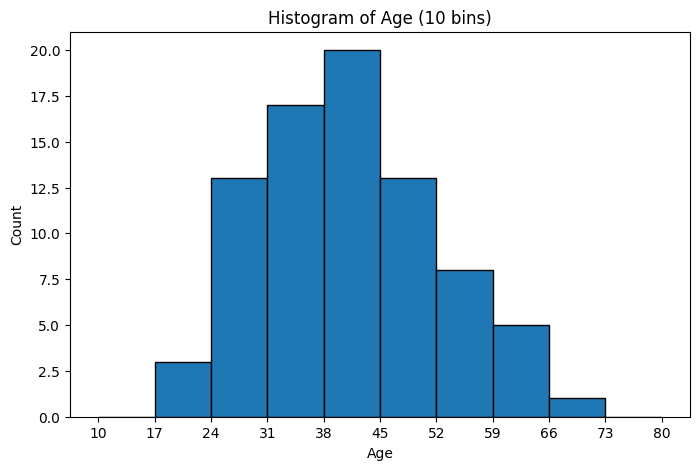


Exec time:  0.07554369996068999


In [37]:
start_time = timeit.default_timer()
ages = df['age'].dropna()
bins = [10, 17, 24, 31, 38, 45, 52, 59, 66, 73, 80]
plt.figure(figsize=(8, 5))
plt.hist(ages, bins=bins, edgecolor='black')
plt.xlabel('Age')
plt.ylabel('Count')
plt.title('Histogram of Age (10 bins)')
plt.xticks(bins)
plt.show()
stop_time = timeit.default_timer()
print("\nExec time: ", stop_time - start_time)


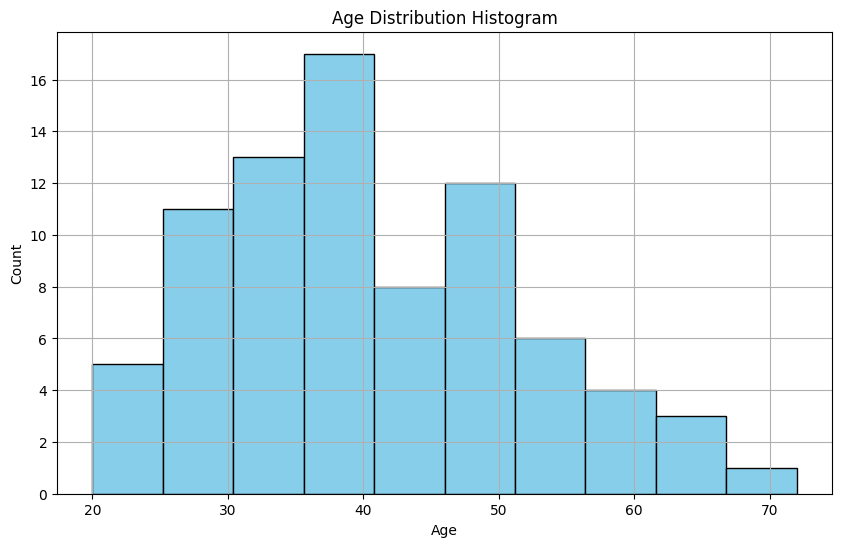


Exec time: 0.07083500002045184


In [46]:

start_time = timeit.default_timer()
age_data = pd.to_numeric(data[:, 1])
min_age = age_data.min()
max_age = age_data.max()
age_ranges = np.linspace(min_age, max_age, 11)

plt.figure(figsize=(10, 6))
plt.hist(age_data, bins=age_ranges, color='skyblue', edgecolor='black')
plt.xlabel('Age')
plt.ylabel('Count')
plt.title('Age Distribution Histogram')
plt.grid(True)
plt.show()

stop_time = timeit.default_timer()
print("\nExec time:", stop_time - start_time)


### Збудувати графік залежності одного integer/real атрибута від іншого.

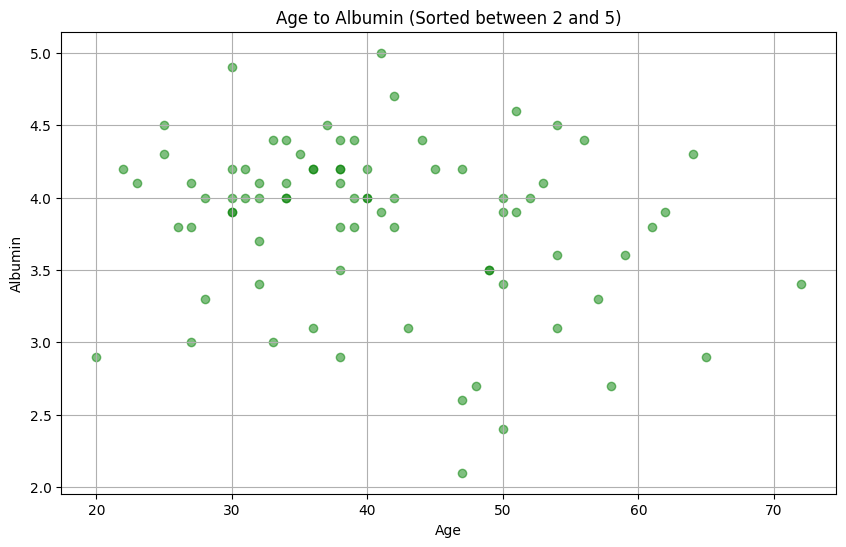


Exec time:  46.05954460002249


In [60]:
df['albumin'] = pd.to_numeric(df['albumin'], errors='coerce')

filtered_df = df[(df['albumin'] >= 2) & (df['albumin'] <= 5)]
filtered_df_sorted = filtered_df.sort_values(by='albumin')

plt.figure(figsize=(10, 6))
plt.scatter(filtered_df_sorted['age'], filtered_df_sorted['albumin'], alpha=0.5, color='green')
plt.xlabel('Age')
plt.ylabel('Albumin')
plt.title('Age to Albumin (Sorted between 2 and 5)')
plt.grid(True)
plt.show()

stop_time = timeit.default_timer()
print("\nExec time: ", stop_time - start_time)


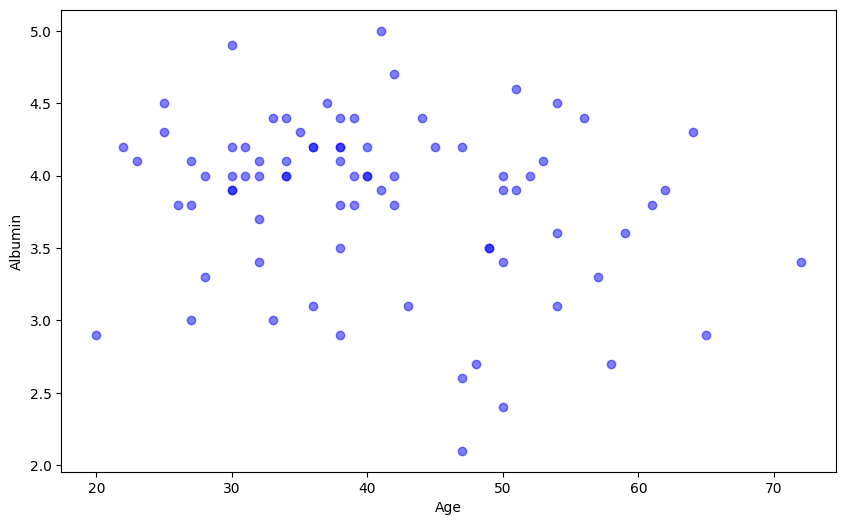


Exec time:  0.07257129997015


In [55]:
start_time = timeit.default_timer()
age_data = pd.to_numeric(data[:, 1])
albumin_data = pd.to_numeric(data[:, 17])
plt.figure(figsize=(10, 6))
plt.scatter(age_data, albumin_data, alpha=0.5, color='blue')
plt.xlabel('Age')
plt.ylabel('Albumin')
plt.show()
stop_time = timeit.default_timer()
print("\nExec time: ", stop_time - start_time)

### Підрахувати коефіцієнт Пірсона та Спірмена для двох integer/real атрибутів.

In [8]:

start_time = timeit.default_timer()
x = df['age'].astype(int)
y = df['albumin'].astype(float)

pearson = df['age'].corr(df['albumin'], method='pearson')
spearman = df['age'].corr(df['albumin'], method='spearman')

stop_time = timeit.default_timer()

print("\nExec time: ", stop_time - start_time)
print("Pirc:", pearson)
print("Spirc:", spearman)



Exec time:  0.0024277999764308333
Pirc: -0.2374222448413437
Spirc: -0.24942615075638966


In [66]:

start_time = timeit.default_timer()
x = data[:, 1].astype(int)
y = data[:, 17].astype(float)

pearson, _ = pearsonr(x, y)
spearman, _ = spearmanr(x, y)

stop_time = timeit.default_timer()

print("\nExec time: ", stop_time - start_time)
print("Pirc:", pearson)
print("Spirc:", spearman)



Exec time:  0.0020721000037156045
Pirc: -0.22046441126028982
Spirc: -0.18882815507787318


### Провести One Hot Encoding категоріального string атрибуту.

In [68]:

df_copy = df.copy()

start_time = timeit.default_timer()
onehotencoder = OneHotEncoder()
x = onehotencoder.fit_transform(df_copy[['sex']]).toarray()

df_result = pd.DataFrame(x, columns=onehotencoder.get_feature_names_out(['sex']))

df_copy = pd.concat([df_copy, df_result], axis=1)
stop_time = timeit.default_timer()

print("\nExec time: ", stop_time - start_time)
print(df_copy.head())




Exec time:  0.026333199988584965
    class   age  sex steroid  antivirals fatigue malaise anorexia liver_big  \
5     2.0  34.0  1.0       2         2.0       2       2        2         2   
10    2.0  39.0  1.0       1         1.0       2       2        2         1   
11    2.0  32.0  1.0       2         1.0       1       2        2         2   
12    2.0  41.0  1.0       2         1.0       1       2        2         2   
13    2.0  30.0  1.0       2         2.0       1       2        2         2   

   liver_firm  ... ascites varices bilirubin alk_phosphate sgot albumin  \
5           2  ...       2       2      0.90            95   28     4.0   
10          1  ...       2       2      1.30            78   30     4.4   
11          1  ...       2       2      1.00            59  249     3.7   
12          1  ...       2       2      0.90            81   60     3.9   
13          1  ...       2       2      2.20            57  144     4.9   

   protime  histology sex_1  sex_2  
5  

In [69]:

data_copy = data.copy()

start_time = timeit.default_timer()

data_encod = data_copy[:, [2]]
onehotencoder = OneHotEncoder()

encoded_data = onehotencoder.fit_transform(data_encod).toarray()
data_encoded = np.hstack((data_copy[:, :6], encoded_data, data_copy[:, 7:]))
stop_time = timeit.default_timer()

print("\nExec time: ", stop_time - start_time)
print(data_encoded[:5])



Exec time:  0.01637599995592609
[['2' '34' '1' '2' '2' '2' '1.0' '0.0' '2' '2' '2' '2' '2' '2' '2' '0.90'
  '95' '28' '4.0' '75' '1']
 ['2' '39' '1' '1' '1' '2' '1.0' '0.0' '2' '1' '1' '2' '2' '2' '2' '1.30'
  '78' '30' '4.4' '85' '1']
 ['2' '32' '1' '2' '1' '1' '1.0' '0.0' '2' '2' '1' '2' '1' '2' '2' '1.00'
  '59' '249' '3.7' '54' '1']
 ['2' '41' '1' '2' '1' '1' '1.0' '0.0' '2' '2' '1' '2' '2' '2' '2' '0.90'
  '81' '60' '3.9' '52' '1']
 ['2' '30' '1' '2' '2' '1' '1.0' '0.0' '2' '2' '1' '2' '2' '2' '2' '2.20'
  '57' '144' '4.9' '78' '1']]


### Провести візуалізацію багатовимірних даних

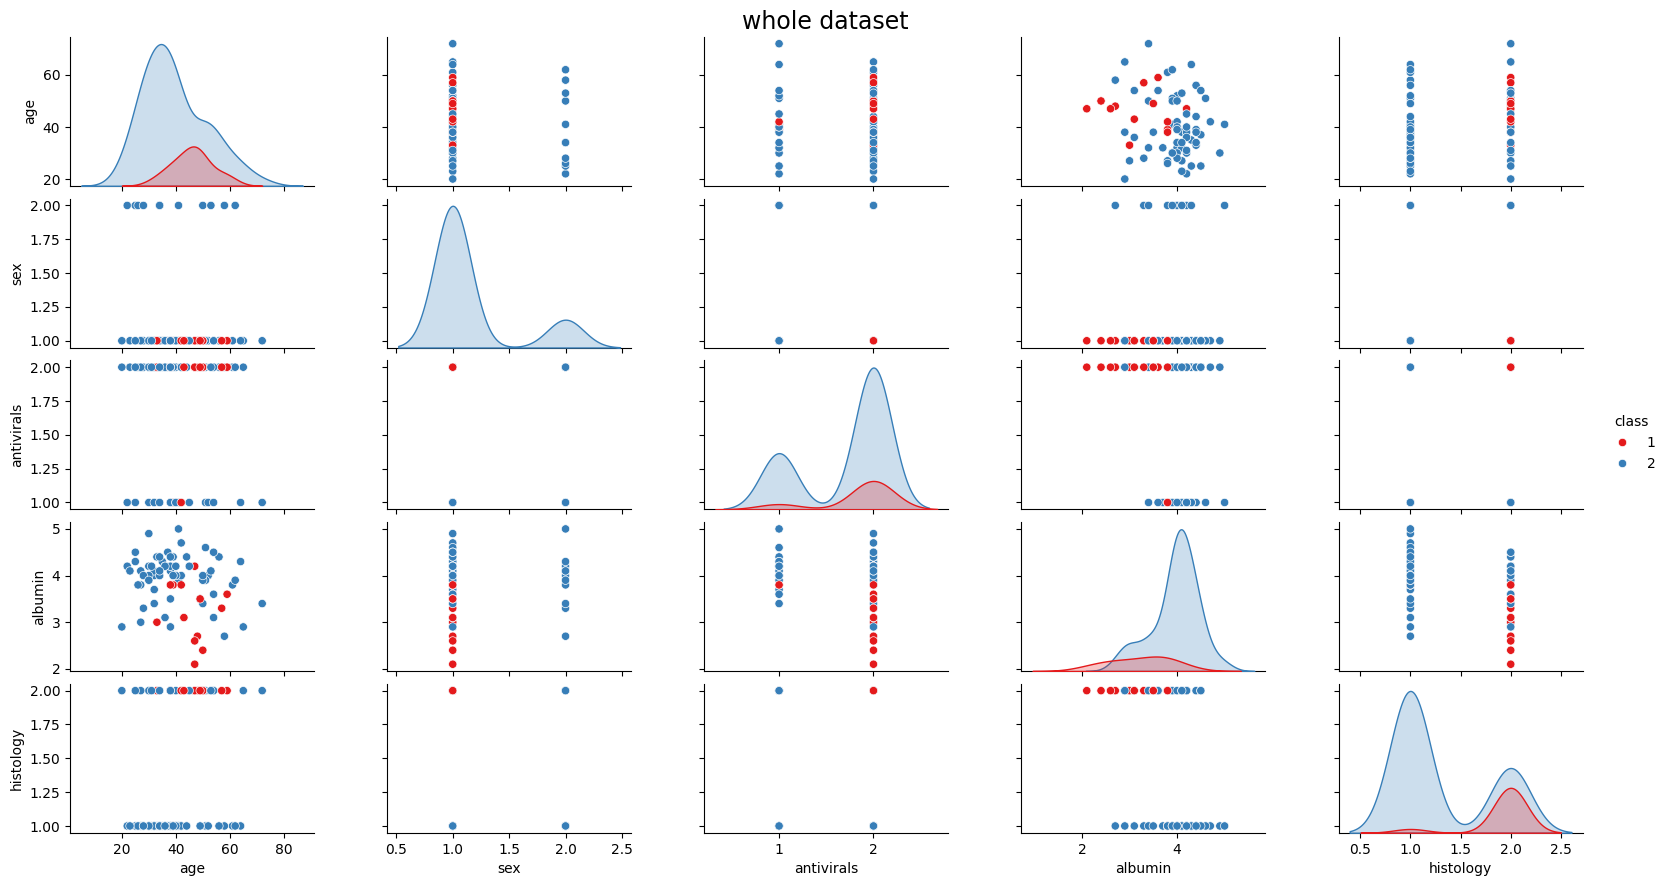


Exec time:  1.760130799957551


In [74]:
start_time = timeit.default_timer()
headers = [
    'class',          # 1. DIE, LIVE
    'age',            # 2. AGE
    'sex',            # 3. SEX
    'steroid',        # 4. STEROID
    'antivirals',     # 5. ANTIVIRALS
    'fatigue',        # 6. FATIGUE
    'malaise',        # 7. MALAISE
    'anorexia',       # 8. ANOREXIA
    'liver_big',      # 9. LIVER BIG
    'liver_firm',     # 10. LIVER FIRM
    'spleen_palpable',# 11. SPLEEN PALPABLE
    'spiders',        # 12. SPIDERS
    'ascites',        # 13. ASCITES
    'varices',        # 14. VARICES
    'bilirubin',      # 15. BILIRUBIN
    'alk_phosphate',  # 16. ALK PHOSPHATE
    'sgot',           # 17. SGOT
    'albumin',        # 18. ALBUMIN
    'protime',        # 19. PROTIME
    'histology'       # 20. HISTOLOGY
]

plot = sns.pairplot(df[headers], hue='class', height=1.8, aspect=1.8, palette='Set1')
fig = plot.figure
fig.subplots_adjust(top=0.95, wspace=0.3)
title = fig.suptitle('whole dataset', fontsize=17)
plt.show()
stop_time = timeit.default_timer()
print("\nExec time: ", stop_time - start_time)


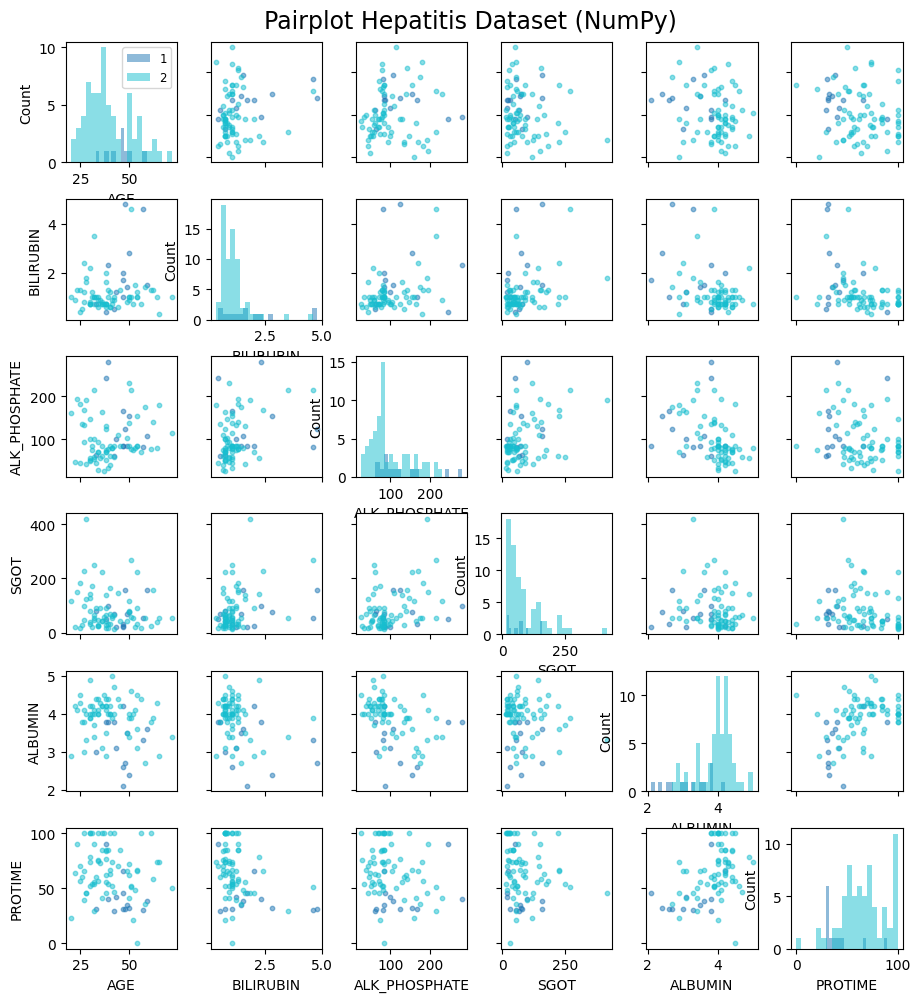


Exec time: 0.95 sec


In [ ]:
start_time = timeit.default_timer()

cols = [
    'Class', 'AGE', 'SEX', 'STEROID', 'ANTIVIRALS', 'FATIGUE', 'MALAISE',
    'ANOREXIA', 'LIVER_BIG', 'LIVER_FIRM', 'SPLEEN_PALPABLE', 'SPIDERS',
    'ASCITES', 'VARICES', 'BILIRUBIN', 'ALK_PHOSPHATE', 'SGOT', 'ALBUMIN',
    'PROTIME', 'HISTOLOGY'
]

numeric_cols = [
    'AGE', 'BILIRUBIN', 'ALK_PHOSPHATE', 'SGOT', 'ALBUMIN', 'PROTIME'
]

numeric_indices = [cols.index(col) for col in numeric_cols]
class_index    = cols.index('Class')

numeric_data = data[:, numeric_indices].astype(float)
hue_labels   = data[:, class_index]

mask = ~np.isnan(numeric_data).all(axis=1)
numeric_data = numeric_data[mask]
hue_labels   = hue_labels[mask]

unique_classes = np.unique(hue_labels)
colors = plt.cm.tab10(np.linspace(0,1,len(unique_classes)))
color_dict = {cls: c for cls,c in zip(unique_classes, colors)}

n_vars = len(numeric_cols)
fig, axes = plt.subplots(n_vars, n_vars, figsize=(1.8*n_vars, 1.8*n_vars))

start_time = timeit.default_timer()
for i in range(n_vars):
    for j in range(n_vars):
        ax = axes[i, j]
        if i == j:
            # диаграмма распределения по классам 
            for cls in unique_classes:
                vals = numeric_data[hue_labels == cls, i]
                ax.hist(vals, bins=20, alpha=0.5,
                        label=cls if j==0 else None,
                        color=color_dict[cls])
            if j == 0:
                ax.legend(loc='upper right', fontsize='small')
            ax.set_xlabel(numeric_cols[j])
            ax.set_ylabel('Count')
        else:
            # scatter plot
            for cls in unique_classes:
                xi = numeric_data[hue_labels == cls, j]
                yi = numeric_data[hue_labels == cls, i]
                ax.scatter(xi, yi, s=10, alpha=0.5,
                           color=color_dict[cls],
                           label=cls if (i==n_vars-1 and j==0) else None)
            if i == n_vars-1:
                ax.set_xlabel(numeric_cols[j])
            else:
                ax.set_xticklabels([])
            if j == 0:
                ax.set_ylabel(numeric_cols[i])
            else:
                ax.set_yticklabels([])

fig.subplots_adjust(top=0.95, wspace=0.3, hspace=0.3)
fig.suptitle('Pairplot Hepatitis Dataset (NumPy)', fontsize=17)
plt.show()

stop_time = timeit.default_timer()
print(f"\nExec time: {stop_time - start_time:.2f} sec")
